# Eksplorativna analiza podataka – Online Poker Games

## Cilj analize

Cilj ove analize je razumevanje strukture skupa podataka koji sadrži informacije o online poker partijama. 

Fokus je na:
- analizi akcija igrača (bet, raise, fold...)
- veličini uloga (bet)
- ishodu ruke (result, balance)
- kontekstu igre (position, stack, pot)

Ova analiza predstavlja osnovu za:
- definisanje blefa
- feature engineering
- izgradnju klasifikacionog modela

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/blef_dataset.csv")


df.head()

,buyin,tourn_id,table,hand_id,date,time,table_size,level,playing,seat,name,stack,position,action_pre,action_flop,action_turn,action_river,all_in,cards,board_flop,board_turn,board_river,combination,pot_pre,pot_flop,pot_turn,pot_river,ante,blinds,bet_pre,bet_flop,bet_turn,bet_river,result,balance
0,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,1,fa538846,500,BTN,folds,x,x,x,False,8d Qh,0,0,0,NaN,30,30,30,30,0,0,0,0,0,0,gave up,0
1,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,2,676c5599,500,SB,folds,x,x,x,False,--,0,0,0,NaN,30,30,30,30,0,10,10,0,0,0,gave up,-10
2,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,3,7055f691,500,BB,x,x,x,x,False,--,0,0,0,NaN,30,30,30,30,0,20,20,0,0,0,took chips,10
3,$0.92+$0.08,2929450288,1,215051520234,2020-06-07,18:15:23,3,1,3,1,fa538846,500,BB,raises,bets-doesn't,x,x,False,Ks 4s,Ad Kh 4c,0,0,NaN,120,180,180,180,0,20,60,60,0,0,took chips,60
4,$0.92+$0.08,2929450288,1,215051520234,2020-06-07,18:15:23,3,1,3,2,676c5599,490,BTN,folds,x,x,x,False,--,Ad Kh 4c,0,0,NaN,120,180,180,180,0,0,0,0,0,0,gave up,0


## Osnovne informacije o datasetu

Analiziramo strukturu skupa podataka, tipove atributa i osnovne statistike.

Jedan red u datasetu predstavlja jednu poker ruku za jednog igrača.

Dataset sadrži veliki broj atributa koji opisuju:

- karakteristike igrača (pozicija, stack)
- tok igre (akcije po fazama: preflop, flop, turn, river)
- finansijske vrednosti (betovi, pot)
- ishod ruke (result, balance)

Posebno su značajne kolone koje opisuju akcije igrača i veličinu uloga, jer su direktno povezane sa analizom blefa.

---



In [3]:
df.columns.tolist()

['buyin',
 'tourn_id',
 'table',
 'hand_id',
 'date',
 'time',
 'table_size',
 'level',
 'playing',
 'seat',
 'name',
 'stack',
 'position',
 'action_pre',
 'action_flop',
 'action_turn',
 'action_river',
 'all_in',
 'cards',
 'board_flop',
 'board_turn',
 'board_river',
 'combination',
 'pot_pre',
 'pot_flop',
 'pot_turn',
 'pot_river',
 'ante',
 'blinds',
 'bet_pre',
 'bet_flop',
 'bet_turn',
 'bet_river',
 'result',
 'balance']

## Provera kvaliteta podataka

Proveravamo:
- nedostajuće vrednosti
- duplikate
- distribuciju kategorijskih vrednosti

In [4]:
df.isnull().sum().sort_values(ascending=False)


combination     84175
tourn_id            0
buyin               0
table               0
hand_id             0
time                0
date                0
level               0
playing             0
seat                0
table_size          0
stack               0
position            0
action_pre          0
action_flop         0
action_turn         0
action_river        0
all_in              0
name                0
cards               0
board_flop          0
board_turn          0
board_river         0
pot_pre             0
pot_flop            0
pot_turn            0
pot_river           0
ante                0
blinds              0
bet_pre             0
bet_flop            0
bet_turn            0
bet_river           0
result              0
balance             0
dtype: int64

Kolona `combination` sadrži veliki broj nedostajućih vrednosti, što je očekivano jer se kombinacija karata vidi samo u slučajevima kada dođe do showdown-a.


In [5]:
df.duplicated().sum()

np.int64(0)

Nisu pronađeni duplikati u datasetu.

In [6]:
for col in ["action_pre", "action_flop", "action_turn", "action_river", "result", "position"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


action_pre
action_pre
folds                        32900
calls                        20717
raises                       12097
checks                       11837
doesn't                       7647
raises-doesn't                7447
calls-calls                   2722
calls-folds                   2640
x                             2044
raises-calls                  1541
raises-folds                   514
calls-raises                   187
raises-raises                  180
calls-doesn't                   34
calls-raises-doesn't            26
calls-raises-calls              19
raises-raises-calls             18
raises-raises-doesn't           13
raises-shows                     7
shows                            5
raises-raises-raises             4
calls-calls-calls                4
calls-raises-raises              3
raises-calls-calls               3
calls-calls-folds                2
calls-raises-raises-calls        1
calls-calls-raises               1
raises-raises-folds             

Akcije igrača su predstavljene kategorijskim vrednostima i deluju konzistentno.

## Pretprocesiranje podataka

Potrebno je izvršiti osnovnu pripremu podataka kako bi analiza bila pouzdana i kako bi se kasnije ovaj skup mogao povezati sa modelom za procenu jačine ruke.

Pošto je cilj projekta detekcija blefa, a blef zavisi i od ponašanja igrača i od objektivne jačine ruke, u ovoj fazi pretprocesiranja fokus je na:

- standardizaciji tekstualnih vrednosti
- konverziji datuma i vremena
- parsiranju privatnih i zajedničkih karata
- formiranju pomoćnih atributa koji će biti korisni u daljoj analizi i kasnijoj proceni jačine ruke

### Standardizacija tekstualnih vrednosti

In [7]:
text_cols = [
    "position",
    "action_pre",
    "action_flop",
    "action_turn",
    "action_river",
    "result",
    "cards",
    "board_flop",
    "board_turn",
    "board_river",
    "combination"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

### Konverzija datuma i vremena

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce").dt.time

df["datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["time"].astype(str),
    errors="coerce"
)

### Parsiranje karata

Karte su parsirane iz string formata u listu kako bi se omogućila dalja analiza.

- `hole_cards` predstavljaju privatne karte igrača
- `flop_cards`, `turn_card` i `river_card` predstavljaju zajedničke karte

Vrednosti poput "0" ili "--" označavaju da karte nisu dostupne.

In [9]:
def parse_cards(value):
    value = str(value).strip().lower()
    
    if value in ["0", "--", "nan", "none"]:
        return []
    
    return value.split()

# privatne karte
df["hole_cards"] = df["cards"].apply(parse_cards)

# zajedničke karte
df["flop_cards"] = df["board_flop"].apply(parse_cards)
df["turn_card"] = df["board_turn"].apply(parse_cards)
df["river_card"] = df["board_river"].apply(parse_cards)

### Formiranje pomoćnih atributa

In [10]:
df["board_flop_full"] = df["flop_cards"]
df["board_turn_full"] = df["flop_cards"] + df["turn_card"]
df["board_river_full"] = df["flop_cards"] + df["turn_card"] + df["river_card"]

Formirani su atributi koji predstavljaju stanje table u svakoj fazi igre:

- flop
- turn
- river

Ovo je važno jer će se upravo ovi podaci koristiti kao ulaz za model koji procenjuje jačinu ruke.

In [11]:
df["num_hole"] = df["hole_cards"].apply(len)
df["num_flop"] = df["flop_cards"].apply(len)
df["num_turn"] = df["turn_card"].apply(len)
df["num_river"] = df["river_card"].apply(len)

df["has_full_hand"] = (df["num_hole"] == 2)
df["has_flop"] = (df["num_flop"] == 3)
df["has_turn"] = (df["num_turn"] == 1)
df["has_river"] = (df["num_river"] == 1)

Kreirani su pomoćni atributi koji pokazuju dostupnost podataka:

- da li su poznate privatne karte
- da li su dostupne zajedničke karte po fazama igre

Ovo je važno za procenu u kojim slučajevima je moguće odrediti jačinu ruke.

In [12]:
print("Ukupno redova:", len(df))
print("Ima hole cards:", (df["has_full_hand"]).sum())
print("Ima flop:", (df["has_flop"]).sum())
print("Ima turn:", (df["has_turn"]).sum())
print("Ima river:", (df["has_river"]).sum())

Ukupno redova: 102615
Ima hole cards: 54294
Ima flop: 57271
Ima turn: 39351
Ima river: 32496


Na osnovu ovih rezultata može se proceniti u kom procentu slučajeva je moguće rekonstruisati ruku igrača i primeniti model za procenu jačine ruke.

Ovaj korak je ključan za povezivanje dataset-a sa modelom razvijenim u prethodnoj fazi projekta.

## Povezivanje novog dataset-a sa modelom za procenu jačine ruke

U ovom delu koristi se model istreniran na skupu `poker_dataset.csv` za procenu jačine ruke u novom skupu podataka.

Pristup je sledeći:

1. Na skupu `poker_dataset.csv` trenira se model za klasifikaciju jačine ruke.
2. U novom skupu se iz privatnih i zajedničkih karata rekonstruišu kombinacije na flopu i turnu.
3. Na osnovu tih informacija formiraju se ulazni atributi istog tipa kao u prethodnom modelu.
4. Model zatim predviđa kategoriju jačine ruke za redove u kojima su privatne karte poznate.

Na ovaj način se novi skup podataka povezuje sa prethodno razvijenim delom projekta.

In [13]:
import joblib

model = joblib.load("../model/hand_strength_model.pkl")
model_columns = joblib.load("../model/hand_strength_model_columns.pkl")


In [14]:
import sys
from pathlib import Path

src_path = (Path.cwd() / "../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from blef import best_hand_class, max_card_from_hole, same_suit_from_hole

df["result1_class"] = df.apply(
    lambda row: best_hand_class(row["hole_cards"] + row["board_flop_full"])
    if isinstance(row["hole_cards"], list) and isinstance(row["board_flop_full"], list) and len(row["hole_cards"]) == 2 and len(row["board_flop_full"]) == 3
    else np.nan,
    axis=1
)

df["result2_class"] = df.apply(
    lambda row: best_hand_class(row["hole_cards"] + row["board_turn_full"])
    if isinstance(row["hole_cards"], list) and isinstance(row["board_turn_full"], list) and len(row["hole_cards"]) == 2 and len(row["board_turn_full"]) == 4
    else np.nan,
    axis=1
)

df["max_card"] = df["hole_cards"].apply(
    lambda cards: max_card_from_hole(cards) if isinstance(cards, list) and len(cards) == 2 else np.nan
)

df["same_suit"] = df["hole_cards"].apply(
    lambda cards: same_suit_from_hole(cards) if isinstance(cards, list) and len(cards) == 2 else np.nan
)

In [15]:
df_model = df.dropna(subset=["result1_class", "result2_class", "max_card", "same_suit"]).copy()

X_cat = pd.get_dummies(df_model[["result1_class", "result2_class"]])
X_num = df_model[["max_card", "same_suit"]]

X = pd.concat([X_cat, X_num], axis=1)

for col in model_columns:
    if col not in X.columns:
        X[col] = 0

X = X[model_columns]

In [16]:
df_model["predicted_hand_strength"] = model.predict(X)

In [17]:
if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X)
    probs_df = pd.DataFrame(probs, columns=model.classes_, index=df_model.index)
    probs_df = probs_df.add_prefix("proba_")
    df_model = pd.concat([df_model, probs_df], axis=1)

In [18]:
df["predicted_hand_strength"] = None
df.loc[df_model.index, "predicted_hand_strength"] = df_model["predicted_hand_strength"].astype(str)

In [19]:
for col in probs_df.columns:
    df[col] = np.nan
    df.loc[df_model.index, col] = df_model[col]

### Distribucija jačine ruke

Na sledećem grafiku prikazana je distribucija predviđene jačine ruke.

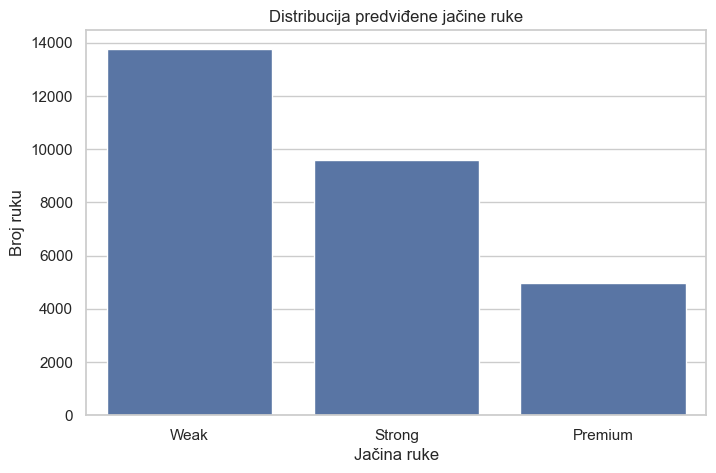

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df[df["predicted_hand_strength"].notna()],
    x="predicted_hand_strength",
    order=df["predicted_hand_strength"].value_counts().index
)
plt.title("Distribucija predviđene jačine ruke")
plt.xlabel("Jačina ruke")
plt.ylabel("Broj ruku")
plt.show()

Najveći broj ruku pripada kategoriji slabih ruku (Weak), što je u skladu sa očekivanjima u pokeru. Jake (Strong) i posebno premium ruke (Premium) javljaju se znatno ređe.

Ovakva distribucija potvrđuje da model daje realistične rezultate i da se ponaša u skladu sa pravilima igre.

### Pokrivenost modela

Model nije mogao da izvrši procenu za sve instance iz skupa podataka, već samo za podskup ruku za koje su dostupni svi potrebni atributi (flop, turn i validne karte).

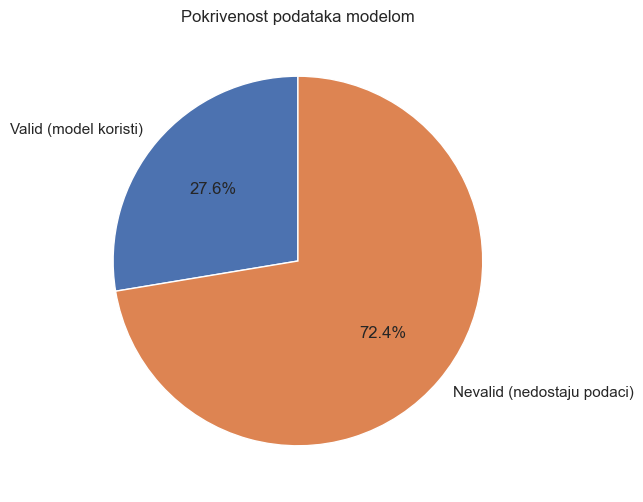

In [21]:
valid = len(df_model)
invalid = len(df) - valid

plt.figure(figsize=(6,6))
plt.pie(
    [valid, invalid],
    labels=["Valid (model koristi)", "Nevalid (nedostaju podaci)"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pokrivenost podataka modelom")
plt.show()

#### Komentar

Model je primenljiv na deo skupa podataka za koji su dostupni svi potrebni atributi (kompletne informacije o kartama i fazama igre).

Preostali deo podataka nije moguće obraditi jer nedostaju informacije potrebne za rekonstrukciju ruke (npr. flop ili turn).

Iako model ne pokriva ceo skup, broj validnih instanci je dovoljan za dalju analizu i treniranje modela za detekciju blefa.

## Definicija blefa

Pošto dataset ne sadrži eksplicitnu oznaku da li je potez blef, uvedena je heuristička definicija blefa.

U ovom radu blef se definiše kao situacija u kojoj su ispunjeni sledeći uslovi:

- procenjena jačina ruke je slaba (`Weak`)
- igrač je izvršio agresivnu akciju u nekoj fazi igre
- ruka nije završena showdown-om

Agresivna akcija se ovde aproksimira pojavom obrazaca kao što su `bet` ili `raise` u kolonama `action_pre`, `action_flop`, `action_turn` i `action_river`.

Ovakva definicija predstavlja pojednostavljenu, ali praktično upotrebljivu aproksimaciju blefa u skupu podataka.

In [25]:
from blef import is_aggressive_action

df_valid = df[df["predicted_hand_strength"].notna()].copy()

df_valid["aggressive"] = df_valid.apply(is_aggressive_action, axis=1)

df_valid["total_bet"] = (
    df_valid["bet_pre"] +
    df_valid["bet_flop"] +
    df_valid["bet_turn"] +
    df_valid["bet_river"]
)

df_valid["is_bluff"] = (
    (df_valid["predicted_hand_strength"] == "Weak") &
    (df_valid["aggressive"] == 1) &
    (df_valid["total_bet"] > 0) &
    (~df_valid["result"].astype(str).str.lower().str.contains("show", na=False))
)

In [26]:
print(df_valid["is_bluff"].value_counts())
print(df_valid["is_bluff"].value_counts(normalize=True))

is_bluff
False    21668
True      6668
Name: count, dtype: int64
is_bluff
False    0.764681
True     0.235319
Name: proportion, dtype: float64


### Komentar

Na osnovu uvedene heuristike izdvojene su situacije koje mogu predstavljati blef.

Očekivano je da blef situacije čine manji deo svih validnih instanci, jer većina poteza u pokeru nije blef. Istovremeno, prisustvo dovoljnog broja ovakvih primera omogućava dalju analizu i treniranje klasifikacionih modela.

Važno je naglasiti da ovakva definicija blefa nije savršena, već predstavlja aproksimaciju zasnovanu na dostupnim podacima. Ipak, ona je dovoljno informativna za potrebe projekta i omogućava povezivanje procene jačine ruke sa obrascima ponašanja igrača.

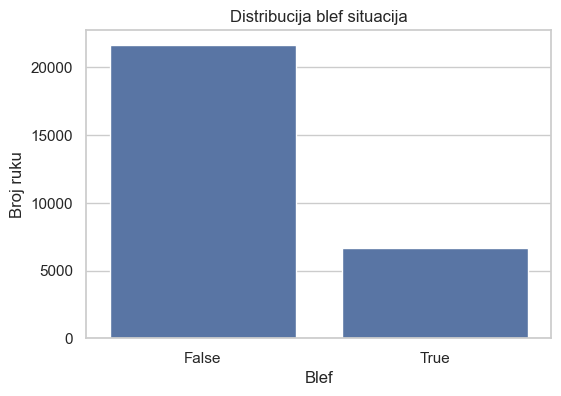

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_valid, x="is_bluff")
plt.title("Distribucija blef situacija")
plt.xlabel("Blef")
plt.ylabel("Broj ruku")
plt.show()

### Distribucija blef situacija

Na grafikonu je prikazana raspodela instanci koje su označene kao blef i onih koje to nisu.

#### Komentar

Rezultati pokazuju da blef situacije predstavljaju manjinski deo skupa podataka, što je u skladu sa očekivanjima. Takva raspodela je karakteristična za realne poker podatke, gde se blef ne javlja u svakoj ruci, već samo u određenim situacijama.